<a href="https://colab.research.google.com/github/slover1126/slover1126/blob/main/%ED%95%B8%EC%A6%88%EC%98%A8_%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D_4%EC%9E%A5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**4장. 모델 훈련**



*   여태까지는 모델을 블랙박스로 여기고 작동 방식에 대한 이해는 하지 않았음
*   그러나 작동 방식의 이해는 적절한 모델 선태그 훈련 알고리즘 최적화, 효율적인 하이퍼파라미터 설정에 큰 도움이 됨
*   선형회귀->다항회귀->로지스틱& 소프트맥스 회귀와 과대적합 탐지 및 방지를 위한 규제를 다룸


**4.1 선형 회귀**

$$\hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_n x_n$$

*   y_hat: 예측치, 세타0:절편, 세타1,2,...n:기울기(회귀계수), x1,2,...,n: 변수의 수인 선형 결합으로 표현됨

$$\hat{y} = h_{\boldsymbol{\theta}}(\mathbf{x}) = \boldsymbol{\theta}^T \mathbf{x}$$

*   위와 같이 벡터 형태로도 적을수 있음
*   세타^T: 파라미터 벡터(행벡터)/x벡터: 변수의 열벡터



**4.1.1 정규 방정식**
$$\hat{\boldsymbol{\theta}} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$


*   비용함수인 RMSE를 최소화하는 수학 공식이 있음
*   위와 같은 공식을 **정규방정식**이라고 함*4.1.1 정규 방정식**
$$\hat{\boldsymbol{\theta}} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$


*   비용함수인 RMSE를 최소화하는 수학 공식이 있음
*   위와 같은 공식을 **정규방정식**이라고 함
*   세타_hat은 비용함수를 최소화 하는 세타값
*   y는 타깃 벡터



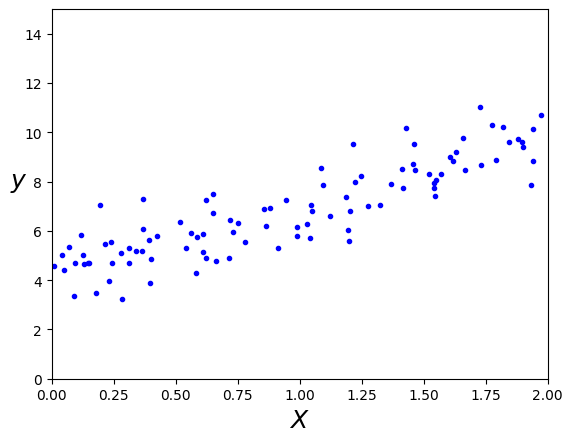

In [1]:
#랜덤 데이터 생성
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
m=100 #샘플 개수
X = 2*np.random.rand(m,1) # 열 벡터 np.random.randn(m,1)->0~1 사이에서 난수를 뽑아 (m,1)사이즈의 벡터 생성
#print(X)
y = 4 + 3*X+np.random.randn(m,1) #열 벡터

plt.plot(X, y, "b.")
plt.xlabel("$X$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([0, 2, 0, 15])
plt.show()

In [2]:
#정규 방정식을 통해 계수행렬 구하기
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X) #모든 샘플 앞에 1 추가(절편 계산용)
theta_best = np.linalg.inv(X_b.T@X_b)@X_b.T@y #정규 방정식 구현
theta_best #절편=4, x1의 계수 3을 기대했으나 차이 발생

array([[4.21509616],
       [2.77011339]])

In [3]:
#세타 햇으로 예측
X_new = np.array([[0],[2]]) #새로운 입력값
X_new_b = add_dummy_feature(X_new) #앞에 1추가
y_predict = X_new_b @theta_best #행렬연산 (x가 0일때, 1일때 예측값)
y_predict

array([[4.21509616],
       [9.75532293]])

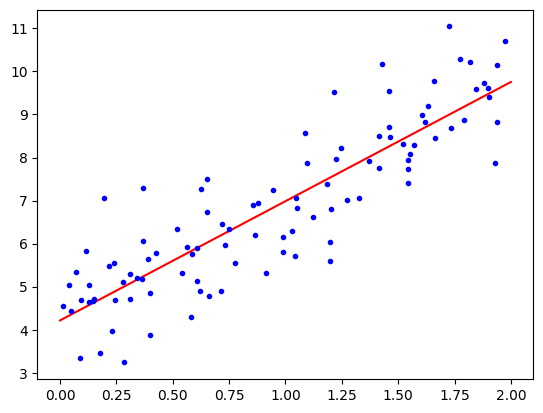

In [4]:
#예측을 그래프로 그려보기
import matplotlib.pyplot as plt

plt.plot(X_new, y_predict, "r-", label = "예측")
plt.plot(X, y,"b.")

plt.show()
#주황색 실선이 선형모델의 예측치를 이어준 값임

In [5]:
#사이킷런에서 선형 회귀 구현(Regreeion 클래스)
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression() #빈 모델 생성
lin_reg.fit(X,y) #적합시키기

print(lin_reg.intercept_, lin_reg.coef_) #절편과 계수 출력
print(lin_reg.predict(X_new)) #X_new에 대한 예측치 출력

[4.21509616] [[2.77011339]]
[[4.21509616]
 [9.75532293]]


In [6]:
#scipy.linalg.lstsq() 함수로 구현(유사역행렬과 SVD 원리 이용)
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b,y,rcond=1e-6)
print(theta_best_svd)

print(np.linalg.pinv(X_b)@y)

[[4.21509616]
 [2.77011339]]
[[4.21509616]
 [2.77011339]]


**유사역행렬과 특이값 분해**


1.   **유사역행렬**


    *   역행렬이 존재하지 않는 행렬에 대해서도 곱셈 시 단위행렬과 비슷한 결과가 나오도록 하는 행렬


2.   **특이값 분해**

    *행렬을 세가지 곱으로 분해하는 방법(외웠으나 까먹음, 나중에 필요하면
    찾아볼것)

3. 위 두가지 방법으로 X^TX의 역행렬이 없는 경우라도 유사역행렬을 구해서 정규방정식처럼 사용할 수 있음

**4.1.2 계산 복잡도**


*   정규방정식의 역행렬을 계산하는 계산 복잡도는 **O(n^2.4)** 에서 **O(n^2.4)** 사이임 (즉 특성수 n이 2배가 되면 계산 시간이 5.3~8배가 됨)

*   LinearRegression 클래스의 SVD 방법은 **O(n^2)** 임

* 학습된 선형 회귀 모델은 예측이 빠르고 예측 계산 복잡도는 샘플수와 특성 수에 선형적임



**4.2 경사 하강법**



1.   경사 하강법은 비용함수를 최소화하는 파라미터를 찾는것
2.   MSE를 예로 들면, 과정은 다음과 같음


    *   초기에 비용함수 위의 랜덤한 한 점을 잡음(랜덤 초기화)
    *   MSE는 2차함수기 때문에 미분하면 해당 점에서의 기울기가 나옴
    *   기울기가 양수라면 왼쪽이 최소점, 기울기가 음수라면 오른쪽이 최소점이 됨
    *   기울기 부호의 반대 방향으로 점을 이동시켜 최소점을 찾음
    *   기울기가 0이 되는 지점이 비용함수(MSE)가 최소가 되는 점임


3.   이때, 얼마만큼 점을 움직일지 정하는 하이퍼파라미터를 **학습률** 이라고 함
4.   학습률이 너무 작다면 많이 반복해야 하므로 시간이 오래 걸리고, 학습률이 크다면 점이 더 높은곳으로 튈수도 있음
5.  비용 함수가 오목하지 않은 경우 어디서 시작하냐에 따라 전역 최솟값(전체 비용함수 그래프 중 가장 낮은 지점)에 도달하지 못하고 지역 최솟값(접선의 기울기가 0이 되는 지점)에 도달할 수도 있음
6.  경사 하강법 사용 시 특성 스케일링을 같게 적용해야 수렴 속도가 상승함








**4.2.1 배치 경사 하강법**


*   경사 하강법을 위해 각 파라미터에 대하여 편도함수(각 파라미터가 조금 변할 때 비용함수의 변화량)를 계산해야함
*   비용함수(MSE)에 대한 편도함수는 다음과 같이 계산됨
$$\frac{\partial}{\partial \theta_j} MSE(\boldsymbol{\theta}) = \frac{2}{m} \sum_{i=1}^{m} \left( \boldsymbol{\theta}^T \mathbf{x}^{(i)} - y^{(i)} \right) x_j^{(i)}$$
*   그리고 각 변수에 대해서 편미분한 함수를 모아둔 벡터를 **그레디언트 벡터**라고 함(다음과 같이 계산됨)
$$\nabla_{\boldsymbol{\theta}} MSE(\boldsymbol{\theta}) = \begin{bmatrix} \frac{\partial}{\partial \theta_0} MSE(\boldsymbol{\theta}) \\ \frac{\partial}{\partial \theta_1} MSE(\boldsymbol{\theta}) \\ \vdots \\ \frac{\partial}{\partial \theta_n} MSE(\boldsymbol{\theta}) \end{bmatrix} = \frac{2}{m} \mathbf{X}^T (\mathbf{X} \boldsymbol{\theta} - \mathbf{y})$$
*   이 공식을 매 단계에서 전체 훈련세트를 활용하여 진행하는 방식을 **배치 경사 하강법** 이라고 함

*   그레디언트 벡터를 구한 후 반대방향으로 가기 위해 사전에 정한 학습률만큼 이동함(에타:학습률)

$$\boldsymbol{\theta}^{(\text{next step})} = \boldsymbol{\theta} - \eta \nabla_{\boldsymbol{\theta}} MSE(\boldsymbol{\theta})$$




초기화: $\theta$를 랜덤 숫자로 시작한다.

예측: 현재 $\theta$와 모든 데이터($X$)를 곱해 예측값($\hat{y}$)들을 구한다.

오차 측정: 실제 정답($y$)과 비교해서 **오차($\hat{y} - y$)**를 구한다.

나침반 계산 (Gradient):각 샘플의 **(오차 $\times$ 변수값)**을 계산한다.

이 값들을 **전부 더해서 평균($2/m$)**을 낸다. (이것이 그레이디언트 벡터!)

이동 (Update): 원래 $\theta$에서 **(학습률 $\times$ 나침반)**만큼 뺀다.

반복: 이 짓을 정해진 횟수만큼 반복한다.

In [10]:
#구현해보기
eta = 0.1 #학습률
n_epochs = 1000
m = len(X_b) #샘플 수

np.random.seed(42)
theta = np.random.randn(2,1) #모델 파라미터를 랜덤하게 초기화

for epoch in range(n_epochs):
    gradients = 2/m *X_b.T @ (X_b @ theta - y)
    theta = theta - eta * gradients
print(theta)
#훈련 세트를 한번 반복하는걸 에포크 라고 함

[[4.21509616]
 [2.77011339]]
